# Transformada de Lorentz en el Espacio Hiperbólico

## Introducción

La transformada de Lorentz, proveniente de la relatividad especial, es una herramienta fundamental para trabajar en el espacio hiperbólico. En el contexto de análisis de redes complejas, nos permite "movernos" por el espacio hiperbólico manteniendo las distancias geométricas entre nodos, algo crucial para estudiar propiedades locales de la red desde la perspectiva de un nodo específico.

## El Espacio Hiperbólico y sus Modelos

### Modelo de Hiperboloide (Minkowski)
El espacio hiperbólico bidimensional $\mathbb{H}^2$ puede representarse como una hipersuperficie en el espacio de Minkowski $\mathbb{R}^{2,1}$:

$$\mathbb{H}^2 = \{ (x_0, x_1, x_2) \in \mathbb{R}^{2,1} : x_0^2 - x_1^2 - x_2^2 = 1, x_0 > 0 \}$$

La métrica viene dada por:
$$ds^2 = dx_0^2 - dx_1^2 - dx_2^2$$

### Coordenadas Polares Hiperbólicas
Cualquier punto puede expresarse en coordenadas polares $(r, \theta)$:
- $x_0 = \cosh(r)$
- $x_1 = \sinh(r) \cos(\theta)$
- $x_2 = \sinh(r) \sin(\theta)$

Donde $r \geq 0$ es la distancia al origen y $\theta \in [0, 2\pi)$ es el ángulo.

## La Transformada de Lorentz

### Definición Matemática

Una transformada de Lorentz (boost) a lo largo de la dirección $\vec{u} = (u_1, u_2)$ (con $||\vec{u}|| = 1$) viene dada por:

Para un punto $(x_0, x_1, x_2)$:

$$
\begin{cases}
x_0' = \gamma x_0 - \gamma \beta (\vec{x} \cdot \vec{u}) \\
\vec{x}' = \vec{x} + (\gamma - 1)(\vec{x} \cdot \vec{u})\vec{u} - \gamma \beta x_0 \vec{u}
\end{cases}
$$

Donde:
- $\vec{x} = (x_1, x_2)$
- $\beta = \tanh(\eta)$ (rapidez)
- $\gamma = \cosh(\eta) = \frac{1}{\sqrt{1-\beta^2}}$
- $\vec{x} \cdot \vec{u} = x_1 u_1 + x_2 u_2$

### Interpretación Geométrica

La transformada de Lorentz es una **isometría** del espacio hiperbólico, lo que significa que:
- Preserva las distancias hiperbólicas
- Es el equivalente hiperbólico de una rotación + traslación en el espacio euclídeo
- Mapea el espacio hiperbólico sobre sí mismo

## Aplicación: Centrar un Nodo en el Origen

### El Problema
Dado un nodo $P$ con coordenadas $(r_c, \theta_c)$, queremos encontrar una transformada de Lorentz que lo lleve al origen $(0,0)$ del espacio hiperbólico (que en el modelo de hiperboloide corresponde al punto $(1,0,0)$).

### La Solución

1. **Representar el nodo en el hiperboloide**:
   $$P = (\cosh(r_c), \sinh(r_c)\cos(\theta_c), \sinh(r_c)\sin(\theta_c))$$

2. **Calcular la dirección del boost**:
   El vector espacial del punto es $\vec{v} = (\sinh(r_c)\cos(\theta_c), \sinh(r_c)\sin(\theta_c))$
   
   La dirección unitaria del boost será:
   $$\vec{u} = \frac{\vec{v}}{||\vec{v}||} = (\cos(\theta_c), \sin(\theta_c))$$

3. **Determinar los parámetros del boost**:
   - $\gamma = \cosh(r_c)$ (factor de Lorentz)
   - $\beta = \tanh(r_c)$ (velocidad)
   
   Notar que $\gamma\beta = \sinh(r_c)$

4. **Aplicar la transformación**:
   Para cualquier otro punto $Q = (x_0, x_1, x_2)$:

   $$x_0' = x_0\cosh(r_c) - (x_1\cos(\theta_c) + x_2\sin(\theta_c))\sinh(r_c)$$
   $$x_1' = x_1 + (\cosh(r_c)-1)(x_1\cos(\theta_c) + x_2\sin(\theta_c))\cos(\theta_c) - x_0\sinh(r_c)\cos(\theta_c)$$
   $$x_2' = x_2 + (\cosh(r_c)-1)(x_1\cos(\theta_c) + x_2\sin(\theta_c))\sin(\theta_c) - x_0\sinh(r_c)\sin(\theta_c)$$

### Propiedades Importantes

1. **El nodo seleccionado va al origen**:
   Sustituyendo $Q = P$, obtenemos $(1,0,0)$

2. **Preservación de distancias**:
   Para dos puntos cualesquiera $A$ y $B$, la distancia hiperbólica $d_h(A,B)$ se conserva:
   $$d_h(A',B') = d_h(A,B)$$

3. **Involución**: La transformación es reversible:
   $$(x_0', x_1', x_2') \xrightarrow{\text{boost opuesto}} (x_0, x_1, x_2)$$

## Implementación Numérica

### Algoritmo Paso a Paso

```python
def lorentz_boost_centrar(punto_central, puntos_a_transformar):
    """
    Aplica transformada de Lorentz para centrar un punto
    
    Args:
        punto_central: (r_c, theta_c) del punto a centrar
        puntos_a_transformar: lista de puntos (r, theta)
    
    Returns:
        puntos_transformados: lista de puntos (r', theta')
    """
    
    # 1. Extraer coordenadas del punto central
    r_c, theta_c = punto_central
    
    # 2. Calcular parámetros del boost
    gamma = np.cosh(r_c)
    beta = np.tanh(r_c)
    u1 = np.cos(theta_c)
    u2 = np.sin(theta_c)
    
    resultados = []
    
    for r, theta in puntos_a_transformar:
        # 3. Convertir a hiperboloide
        x0 = np.cosh(r)
        x1 = np.sinh(r) * np.cos(theta)
        x2 = np.sinh(r) * np.sin(theta)
        
        # 4. Producto escalar con dirección del boost
        producto = x1*u1 + x2*u2
        
        # 5. Aplicar boost
        x0_nuevo = gamma * x0 - gamma * beta * producto
        x1_nuevo = x1 + (gamma - 1) * producto * u1 - gamma * beta * x0 * u1
        x2_nuevo = x2 + (gamma - 1) * producto * u2 - gamma * beta * x0 * u2
        
        # 6. Volver a coordenadas polares
        r_nuevo = np.arccosh(max(x0_nuevo, 1.0))
        if r_nuevo > 1e-10:
            theta_nuevo = np.arctan2(x2_nuevo, x1_nuevo)
        else:
            theta_nuevo = 0.0
        
        resultados.append((r_nuevo, theta_nuevo))
    
    return resultados
```

## Visualización en el Disco de Poincaré

Para visualizar los resultados, proyectamos al disco de Poincaré mediante la transformación:

$$r_{\text{Poincaré}} = \tanh\left(\frac{r}{2}\right)$$
$$x = r_{\text{Poincaré}} \cos(\theta)$$
$$y = r_{\text{Poincaré}} \sin(\theta)$$

Esta proyección tiene la propiedad de que las geodésicas del espacio hiperbólico se convierten en arcos de círculo perpendiculares al borde del disco.

## Aplicaciones en Análisis de Redes

### ¿Por qué centrar un nodo?

1. **Estudio de vecindarios**: Al centrar un nodo, podemos estudiar su entorno inmediato con mayor claridad
2. **Detección de comunidades**: Nodos del mismo cluster tienden a agruparse alrededor del centro
3. **Análisis de jerarquías**: La distancia radial después de la transformación refleja la "profundidad" en la jerarquía local
4. **Visualización focalizada**: Permite "hacer zoom" en regiones de interés manteniendo la geometría correcta

### Interpretación de Resultados

Después de centrar un nodo:
- El nodo centrado está en $(r=0, \theta=0)$
- Nodos cercanos en la red aparecen cerca del centro
- La distancia radial de otros nodos indica su "distancia hiperbólica" al nodo centrado
- La distribución angular muestra la organización alrededor del nodo


/tmp/ipykernel_1492/1867587805.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_1492/1867587805.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


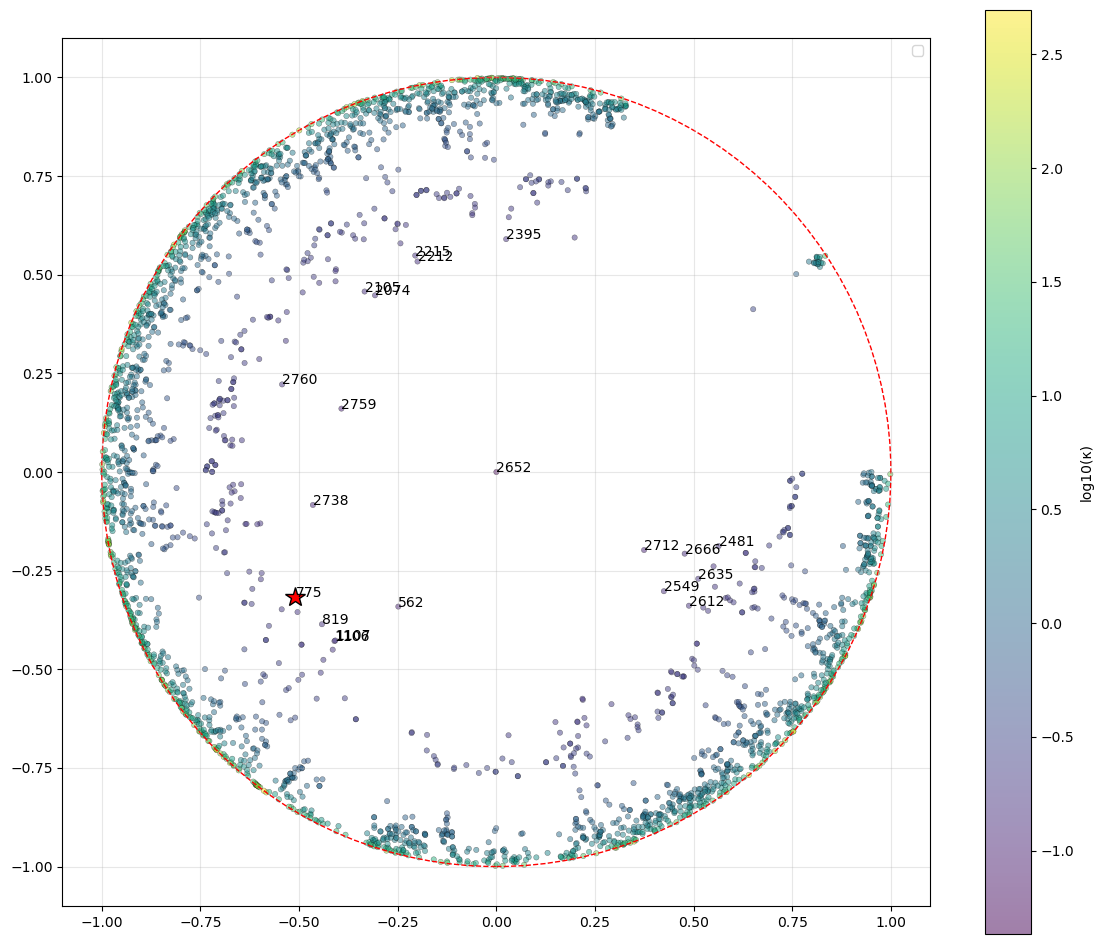

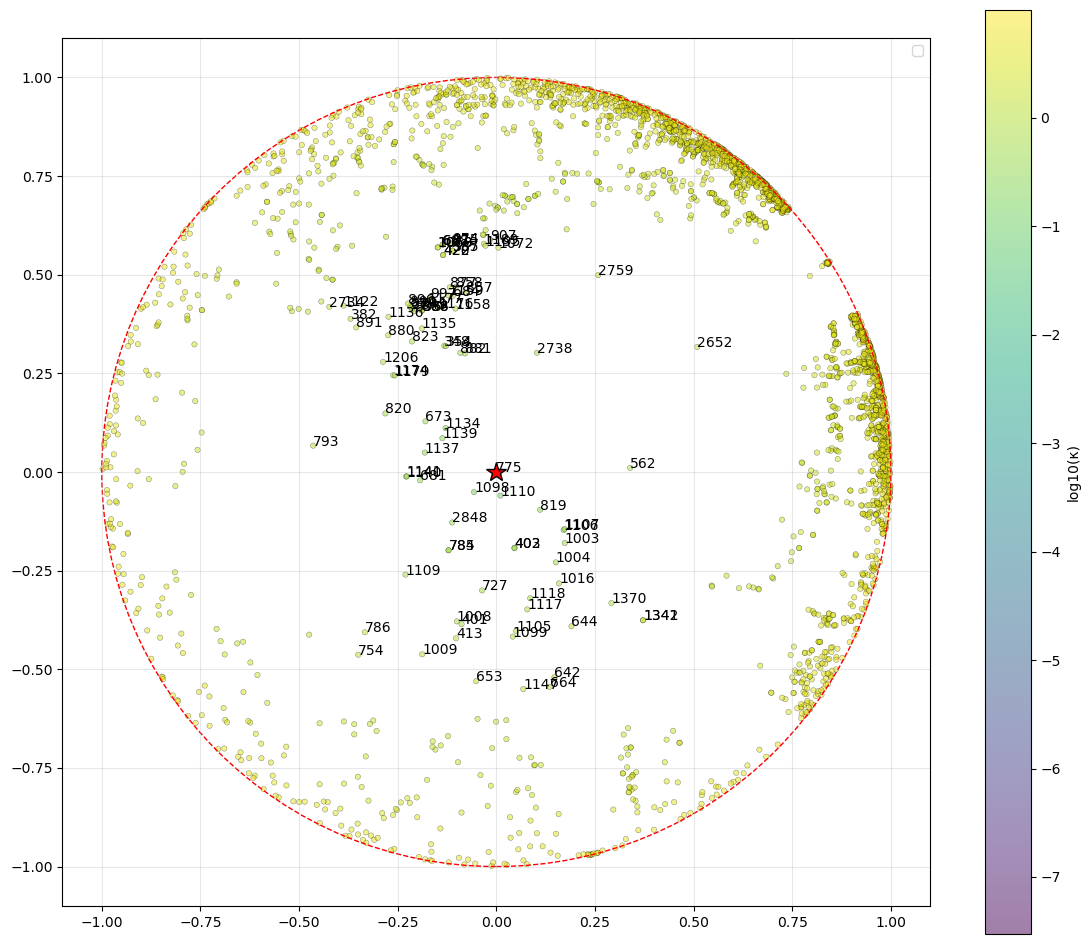

In [64]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

def leer_datos_hiperbolicos(archivo_coords, archivo_edges):
    """
    Lee el grafo y las coordenadas hiperbólicas del formato S1/H2
    """
    # Leer grafo
    G = nx.read_edgelist(archivo_edges)
    
    # Leer coordenadas
    df = pd.read_csv(archivo_coords, sep='\\s+', comment='#', 
                     names=["Vertex", "Inf.Kappa", "Inf.Theta", "Inf.Hyp.Rad."])
    
    # Convertir Vertex a string
    df['Vertex'] = df['Vertex'].astype(str)
    # df = df.set_index('Vertex')
    # Leer parámetros del archivo
    params = {}
    with open(archivo_coords, 'r') as f:
        for line in f:
            if line.startswith('#') and ':' in line:
                parts = line.strip('# ').split(':')
                if len(parts) == 2:
                    key = parts[0].strip()
                    if (key.startswith('-')):
                        key = key[1:].strip()
                    try:
                        params[key] = float(parts[1].strip())
                    except ValueError:
                        params[key] = parts[1].strip()
    
    return G, df, params

def kappa_a_hiperbolico(kappa, kappa_min):
    """
    Convierte κ a coordenada radial hiperbólica
    r = (2/β) * ln(κ/κ_min)
    """
    return np.log(kappa / kappa_min)

def hiperbolico_a_poincare(r_hiperbolico):
    """
    Convierte radio hiperbólico a coordenada en disco de Poincaré
    r_poincare = tanh(r_hiperbolico/2)
    """
    return np.tanh(r_hiperbolico / 2)

def lorentz_boost_para_red(nodes: pd.DataFrame, index_node, kappa_min, precision=1e-10):
    """
    Aplica transformada de Lorentz para centrar un nodo específico.
    Trabaja con coordenadas basadas en κ.
    
    Parámetros:
    -----------
    nodos_dict : dict
        Diccionario con formato {id_nodo: {'kappa': κ, 'theta': θ}}
    index_node : str/int
        Identificador del nodo a centrar
    kappa_min : float
        Valor mínimo de κ en el dataset
    precision : float
        Precisión numérica
    
    Returns:
    --------
    dict : Diccionario con nuevas coordenadas {id_nodo: (r_nueva, theta_nueva)}
    """
    
    # Obtener datos del nodo a centrar
    node = nodes[nodes['Vertex'] == index_node].iloc[0]
    kappa_c = node['Inf.Kappa']
    theta_c = node['Inf.Theta']
    # Calcular radio hiperbólico del nodo central
    r_c = kappa_a_hiperbolico(kappa_c, kappa_min)
    
    # Convertir a coordenadas del hiperboloide
    x0_c = np.cosh(r_c)
    x1_c = np.sinh(r_c) * np.cos(theta_c)
    x2_c = np.sinh(r_c) * np.sin(theta_c)
    
    # Calcular parámetros del boost
    norm = np.sqrt(x1_c**2 + x2_c**2)
    
    if norm > precision:
        u1 = x1_c / norm
        u2 = x2_c / norm
        gamma = x0_c
        beta_boost = np.sqrt(1 - 1/gamma**2) if gamma >= 1 else 0
    else:
        # El nodo ya está en el centro
        return {nodo: (kappa_a_hiperbolico(datos['Inf.Kappa'], kappa_min), datos['Inf.Theta']) 
                for nodo, datos in nodes.items()}
    
    # Aplicar transformación a todos los nodos
    nuevos_nodos = []
    for nodo_id, datos in nodes.iterrows():
        kappa = datos['Inf.Kappa']
        theta = datos['Inf.Theta']
        vertex = datos['Vertex']
        
        # Calcular radio hiperbólico
        r = kappa_a_hiperbolico(kappa, kappa_min)
        
        # Convertir a hiperboloide
        x0 = np.cosh(r)
        x1 = np.sinh(r) * np.cos(theta)
        x2 = np.sinh(r) * np.sin(theta)
        
        # Producto escalar espacial
        x_dot_u = x1*u1 + x2*u2
        
        # Aplicar boost
        x0_nueva = gamma * x0 - gamma * beta_boost * x_dot_u
        x1_nueva = x1 + (gamma - 1) * x_dot_u * u1 - gamma * beta_boost * x0 * u1
        x2_nueva = x2 + (gamma - 1) * x_dot_u * u2 - gamma * beta_boost * x0 * u2
        
        # Asegurar x0_nueva >= 1
        x0_nueva = max(x0_nueva, 1.0)
        
        # Convertir de vuelta a coordenadas hiperbólicas
        r_nueva = np.arccosh(x0_nueva)
        
        # Calcular nuevo ángulo
        if r_nueva > precision:
            sinh_r = np.sinh(r_nueva)
            if sinh_r > 0:
                cos_theta = x1_nueva / sinh_r
                sin_theta = x2_nueva / sinh_r
                cos_theta = np.clip(cos_theta, -1.0, 1.0)
                sin_theta = np.clip(sin_theta, -1.0, 1.0)
                theta_nueva = np.arctan2(sin_theta, cos_theta)
            else:
                theta_nueva = 0.0
        else:
            theta_nueva = 0.0
        
        nuevos_nodos.append({'Vertex': vertex, 'Inf.Kappa': r_nueva, 'Inf.Theta': theta_nueva})
    
    new_df = pd.DataFrame(nuevos_nodos)
    new_df['Vertex'] = new_df['Vertex'].astype(str)
    return new_df


def poincare_disc(data: pd.DataFrame, kappa_min:float, transformed:bool, mark_nodes: list[str] = []):
    fig, ax = plt.subplots(1, 1, figsize=(14, 12), dpi=100)
    x_orig = []
    y_orig = []
    kappa_vals = []
    
    for nodo_id, node_data in data.iterrows():
        # Para la visualización original, usamos los datos del diccionario original
        if not transformed:
            r_orig = kappa_a_hiperbolico(node_data['Inf.Kappa'], kappa_min)
        else:
            r_orig = node_data['Inf.Kappa']
        r_poincare = hiperbolico_a_poincare(r_orig)
        x = r_poincare * np.cos(node_data['Inf.Theta'])
        y = r_poincare * np.sin(node_data['Inf.Theta'])
        x_orig.append(x)
        y_orig.append(y)
        if (r_poincare < 0.6):
            ax.annotate(node_data['Vertex'], (x, y))
        kappa_vals.append(np.log10(node_data['Inf.Kappa']))
    
    scatter = ax.scatter(x_orig, y_orig, c=kappa_vals, cmap='viridis', 
                        s=15, alpha=0.5, edgecolors='black', linewidth=0.3)
    circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--')
    ax.add_patch(circle)
    
    for mark_node in mark_nodes:
        mark_data = data[data['Vertex'] == mark_node].iloc[0]
        if not transformed:
            r_central_orig = kappa_a_hiperbolico(mark_data['Inf.Kappa'], kappa_min)
        else:
            r_central_orig = mark_data['Inf.Kappa']

        r_poincare_central = hiperbolico_a_poincare(r_central_orig)
        x_central = r_poincare_central * np.cos(mark_data['Inf.Theta'])
        y_central = r_poincare_central * np.sin(mark_data['Inf.Theta'])
        ax.plot(x_central, y_central, 'r*', markersize=15, markeredgecolor='black')
    
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.colorbar(scatter, ax=ax, label='log10(κ)')

# Archivos
archivo_coords = "./pipeline-output/.inf_coord"
archivo_edges = "./epidemics-tfg/nets/inf-openflights_GC.edge"

# Leer datos
G, df, params = leer_datos_hiperbolicos(archivo_coords, archivo_edges)

mark = '775'
poincare_disc(df, params['kappa_min'],False, [mark])
tr_df = lorentz_boost_para_red(df, mark, params['kappa_min'])
poincare_disc(tr_df, params['kappa_min'], True, [mark])

Parámetros del modelo:
  beta = 1.1
  kappa_min = 0.042942
  radius_H2 = 35.129
  Nodos en grafo: 2905
  Nodos en coordenadas: 2905

Centrando nodo: 1


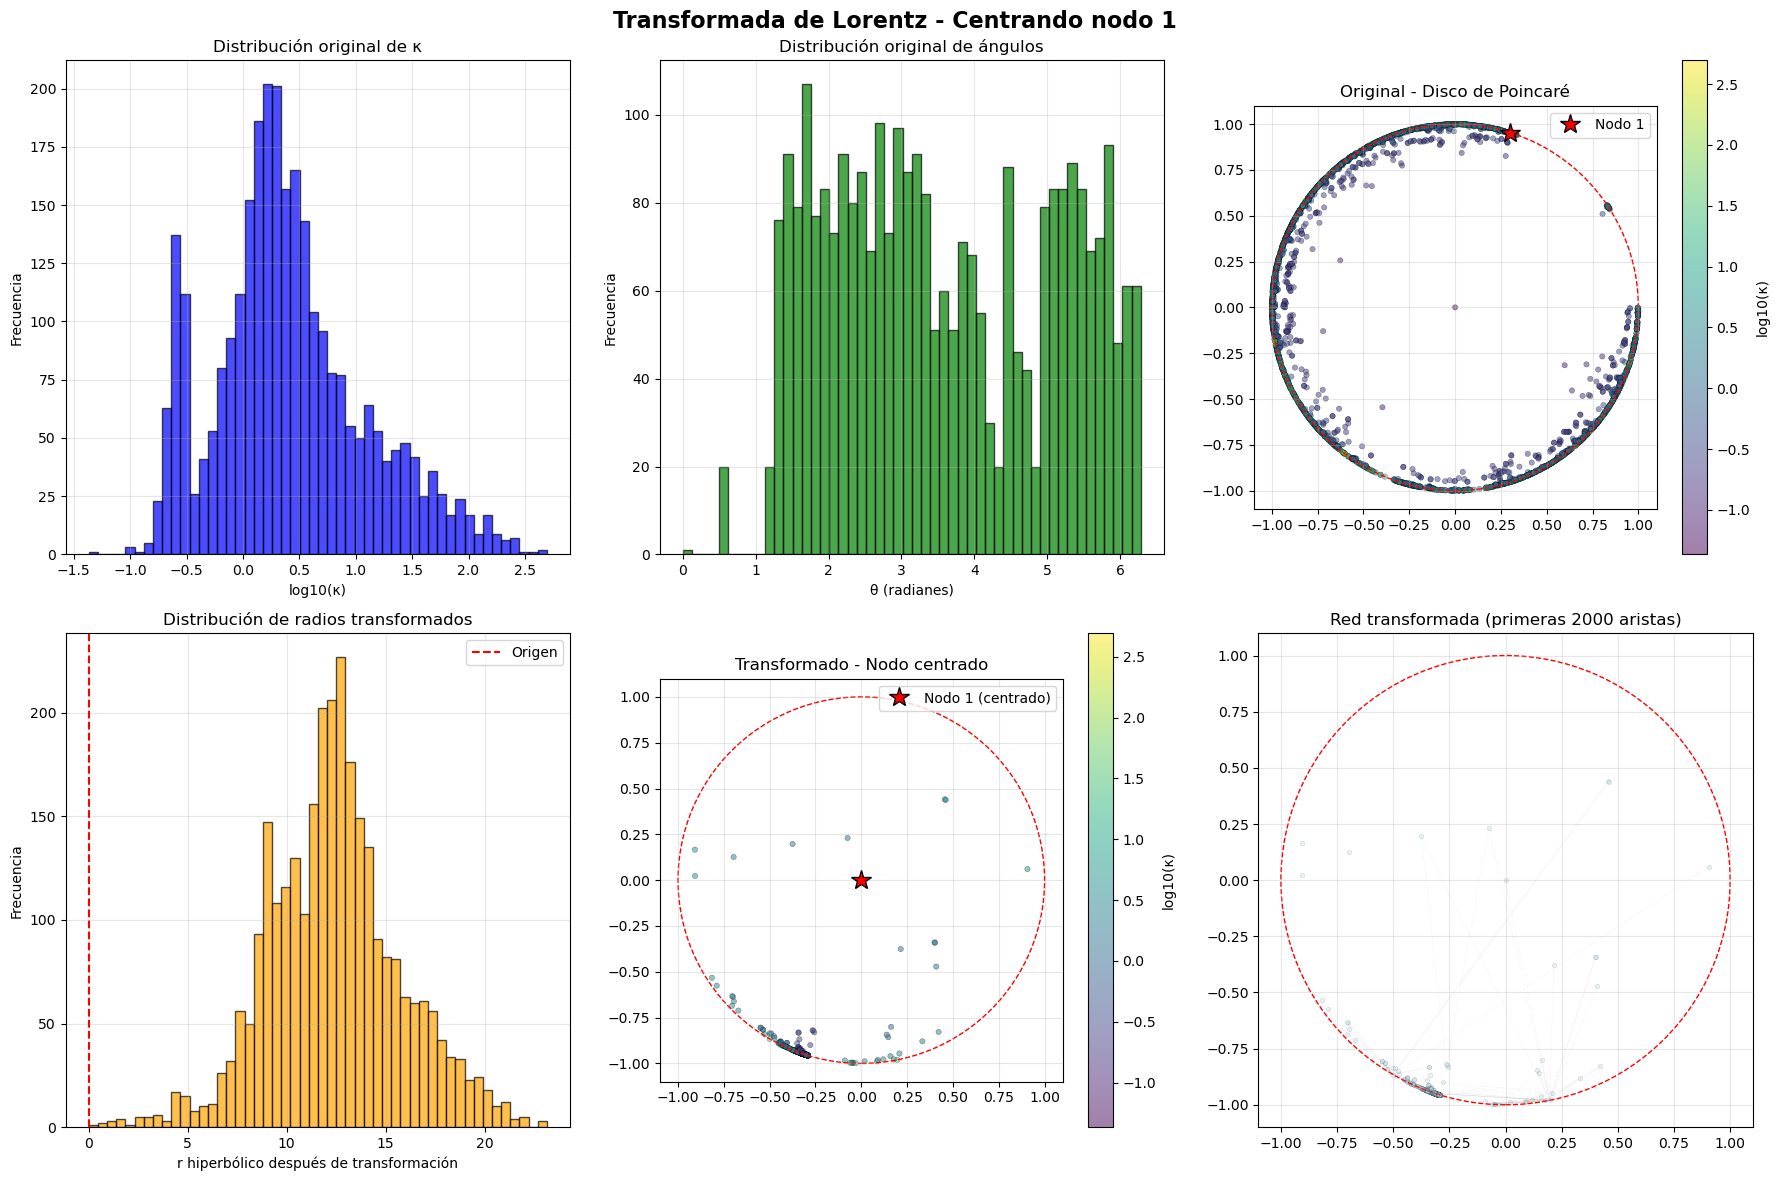


Nodo 1:
  κ = 1.2793
  θ original = 1.2640 rad (72.4°)
  r original = 6.1713
  r después de transformación = 0.000000 (debe ser ~0)
  θ después de transformación = 0.0000 rad


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

def kappa_a_hiperbolico(kappa, kappa_min, beta):
    """
    Convierte κ a coordenada radial hiperbólica
    r = (2/β) * ln(κ/κ_min)
    """
    return (2.0 / beta) * np.log(kappa / kappa_min)

def hiperbolico_a_poincare(r_hiperbolico):
    """
    Convierte radio hiperbólico a coordenada en disco de Poincaré
    r_poincare = tanh(r_hiperbolico/2)
    """
    return np.tanh(r_hiperbolico / 2)

def lorentz_boost_para_red(nodos_dict, nodo_central, kappa_min, beta, precision=1e-10):
    """
    Aplica transformada de Lorentz para centrar un nodo específico.
    Trabaja con coordenadas basadas en κ.
    
    Parámetros:
    -----------
    nodos_dict : dict
        Diccionario con formato {id_nodo: {'kappa': κ, 'theta': θ}}
    nodo_central : str/int
        Identificador del nodo a centrar
    kappa_min : float
        Valor mínimo de κ en el dataset
    beta : float
        Parámetro de dispersión
    precision : float
        Precisión numérica
    
    Returns:
    --------
    dict : Diccionario con nuevas coordenadas {id_nodo: (r_nueva, theta_nueva)}
    """
    
    # Obtener datos del nodo a centrar
    kappa_c = nodos_dict[nodo_central]['kappa']
    theta_c = nodos_dict[nodo_central]['theta']
    
    # Calcular radio hiperbólico del nodo central
    r_c = kappa_a_hiperbolico(kappa_c, kappa_min, beta)
    
    # Convertir a coordenadas del hiperboloide
    x0_c = np.cosh(r_c)
    x1_c = np.sinh(r_c) * np.cos(theta_c)
    x2_c = np.sinh(r_c) * np.sin(theta_c)
    
    # Calcular parámetros del boost
    norm = np.sqrt(x1_c**2 + x2_c**2)
    
    if norm > precision:
        u1 = x1_c / norm
        u2 = x2_c / norm
        gamma = x0_c
        beta_boost = np.sqrt(1 - 1/gamma**2) if gamma >= 1 else 0
    else:
        # El nodo ya está en el centro
        return {nodo: (kappa_a_hiperbolico(datos['kappa'], kappa_min, beta), datos['theta']) 
                for nodo, datos in nodos_dict.items()}
    
    # Aplicar transformación a todos los nodos
    nuevos_nodos = {}
    
    for nodo_id, datos in nodos_dict.items():
        kappa = datos['kappa']
        theta = datos['theta']
        
        # Calcular radio hiperbólico
        r = kappa_a_hiperbolico(kappa, kappa_min, beta)
        
        # Convertir a hiperboloide
        x0 = np.cosh(r)
        x1 = np.sinh(r) * np.cos(theta)
        x2 = np.sinh(r) * np.sin(theta)
        
        # Producto escalar espacial
        x_dot_u = x1*u1 + x2*u2
        
        # Aplicar boost
        x0_nueva = gamma * x0 - gamma * beta_boost * x_dot_u
        x1_nueva = x1 + (gamma - 1) * x_dot_u * u1 - gamma * beta_boost * x0 * u1
        x2_nueva = x2 + (gamma - 1) * x_dot_u * u2 - gamma * beta_boost * x0 * u2
        
        # Asegurar x0_nueva >= 1
        x0_nueva = max(x0_nueva, 1.0)
        
        # Convertir de vuelta a coordenadas hiperbólicas
        r_nueva = np.arccosh(x0_nueva)
        
        # Calcular nuevo ángulo
        if r_nueva > precision:
            sinh_r = np.sinh(r_nueva)
            if sinh_r > 0:
                cos_theta = x1_nueva / sinh_r
                sin_theta = x2_nueva / sinh_r
                cos_theta = np.clip(cos_theta, -1.0, 1.0)
                sin_theta = np.clip(sin_theta, -1.0, 1.0)
                theta_nueva = np.arctan2(sin_theta, cos_theta)
            else:
                theta_nueva = 0.0
        else:
            theta_nueva = 0.0
        
        nuevos_nodos[nodo_id] = (r_nueva, theta_nueva)
    
    return nuevos_nodos

def visualizar_transformacion(G, df, params, nodo_central, num_aristas_mostrar=2000):
    """
    Visualiza el efecto de la transformada de Lorentz
    """
    # Extraer parámetros
    kappa_min = params['kappa_min']
    beta = params['beta']
    
    # Crear diccionario de nodos
    nodos_dict = {}
    for _, row in df.iterrows():
        nodos_dict[str(row['Vertex'])] = {
            'kappa': row['Inf.Kappa'],
            'theta': row['Inf.Theta']
        }
    
    # Aplicar transformación
    nodos_transformados = lorentz_boost_para_red(nodos_dict, str(nodo_central), 
                                                 kappa_min, beta)
    
    # Preparar figura
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # 1. Distribución original de κ
    ax = axes[0]
    ax.hist(np.log10(df['Inf.Kappa']), bins=50, color='blue', alpha=0.7, edgecolor='black')
    ax.set_xlabel('log10(κ)')
    ax.set_ylabel('Frecuencia')
    ax.set_title('Distribución original de κ')
    ax.grid(True, alpha=0.3)
    
    # 2. Distribución original de ángulos
    ax = axes[1]
    ax.hist(df['Inf.Theta'], bins=50, color='green', alpha=0.7, edgecolor='black')
    ax.set_xlabel('θ (radianes)')
    ax.set_ylabel('Frecuencia')
    ax.set_title('Distribución original de ángulos')
    ax.grid(True, alpha=0.3)
    
    # 3. Visualización original en disco de Poincaré
    ax = axes[2]
    x_orig = []
    y_orig = []
    kappa_vals = []
    
    for nodo_id, (r_nuevo, theta_nuevo) in nodos_transformados.items():
        # Para la visualización original, usamos los datos del diccionario original
        datos_orig = nodos_dict[nodo_id]
        r_orig = kappa_a_hiperbolico(datos_orig['kappa'], kappa_min, beta)
        r_poincare = hiperbolico_a_poincare(r_orig)
        x = r_poincare * np.cos(datos_orig['theta'])
        y = r_poincare * np.sin(datos_orig['theta'])
        x_orig.append(x)
        y_orig.append(y)
        kappa_vals.append(np.log10(datos_orig['kappa']))
    
    scatter = ax.scatter(x_orig, y_orig, c=kappa_vals, cmap='viridis', 
                        s=15, alpha=0.5, edgecolors='black', linewidth=0.3)
    circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--')
    ax.add_patch(circle)
    
    # Marcar nodo central
    datos_central = nodos_dict[str(nodo_central)]
    r_central_orig = kappa_a_hiperbolico(datos_central['kappa'], kappa_min, beta)
    r_poincare_central = hiperbolico_a_poincare(r_central_orig)
    x_central = r_poincare_central * np.cos(datos_central['theta'])
    y_central = r_poincare_central * np.sin(datos_central['theta'])
    ax.plot(x_central, y_central, 'r*', markersize=15, markeredgecolor='black', 
            markeredgewidth=1, label=f'Nodo {nodo_central}')
    
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.set_title('Original - Disco de Poincaré')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.colorbar(scatter, ax=ax, label='log10(κ)')
    
    # 4. Distribución de radios después de transformación
    ax = axes[3]
    radios_nuevos = [r for r, _ in nodos_transformados.values()]
    ax.hist(radios_nuevos, bins=50, color='orange', alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', label='Origen')
    ax.set_xlabel('r hiperbólico después de transformación')
    ax.set_ylabel('Frecuencia')
    ax.set_title('Distribución de radios transformados')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # 5. Visualización después de transformación
    ax = axes[4]
    x_new = []
    y_new = []
    
    for nodo_id, (r_nuevo, theta_nuevo) in nodos_transformados.items():
        r_poincare = hiperbolico_a_poincare(r_nuevo)
        x = r_poincare * np.cos(theta_nuevo)
        y = r_poincare * np.sin(theta_nuevo)
        x_new.append(x)
        y_new.append(y)
    
    scatter = ax.scatter(x_new, y_new, c=kappa_vals, cmap='viridis', 
                        s=15, alpha=0.5, edgecolors='black', linewidth=0.3)
    circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--')
    ax.add_patch(circle)
    
    # Marcar nodo central (ahora en el origen)
    ax.plot(0, 0, 'r*', markersize=15, markeredgecolor='black', 
            markeredgewidth=1, label=f'Nodo {nodo_central} (centrado)')
    
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.set_title('Transformado - Nodo centrado')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.colorbar(scatter, ax=ax, label='log10(κ)')
    
    # 6. Red con aristas (transformada)
    ax = axes[5]
    
    # Dibujar nodos
    ax.scatter(x_new, y_new, c='lightblue', s=10, alpha=0.3, edgecolors='black', linewidth=0.2)
    
    # Dibujar una muestra de aristas
    edges_sample = list(G.edges())[:num_aristas_mostrar]
    
    # Crear diccionario de coordenadas transformadas para acceso rápido
    coords_transformadas = {}
    for nodo_id, (r_nuevo, theta_nuevo) in nodos_transformados.items():
        r_poincare = hiperbolico_a_poincare(r_nuevo)
        x = r_poincare * np.cos(theta_nuevo)
        y = r_poincare * np.sin(theta_nuevo)
        coords_transformadas[nodo_id] = (x, y)
    
    for u, v in edges_sample:
        if u in coords_transformadas and v in coords_transformadas:
            x_u, y_u = coords_transformadas[u]
            x_v, y_v = coords_transformadas[v]
            ax.plot([x_u, x_v], [y_u, y_v], 'gray', alpha=0.1, linewidth=0.3)
    
    circle = plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--')
    ax.add_patch(circle)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.set_title(f'Red transformada (primeras {num_aristas_mostrar} aristas)')
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Transformada de Lorentz - Centrando nodo {nodo_central}', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return nodos_transformados

def transformar_y_guardar(df, params, nodo_central, archivo_salida=None):
    """
    Aplica transformación y guarda resultados
    """
    kappa_min = params['kappa_min']
    beta = params['beta']
    
    # Crear diccionario de nodos
    nodos_dict = {}
    for _, row in df.iterrows():
        nodos_dict[str(row['Vertex'])] = {
            'kappa': row['Inf.Kappa'],
            'theta': row['Inf.Theta']
        }
    
    # Aplicar transformación
    nodos_transformados = lorentz_boost_para_red(nodos_dict, str(nodo_central), 
                                                 kappa_min, beta)
    
    # Crear DataFrame con resultados
    resultados = []
    for nodo_id, (r_nuevo, theta_nuevo) in nodos_transformados.items():
        # Recuperar κ original
        kappa_orig = nodos_dict[nodo_id]['kappa']
        resultados.append({
            'Vertex': nodo_id,
            'Original_Kappa': kappa_orig,
            'Original_Theta': nodos_dict[nodo_id]['theta'],
            'Original_Rad': kappa_a_hiperbolico(kappa_orig, kappa_min, beta),
            'Transformado_Rad': r_nuevo,
            'Transformado_Theta': theta_nuevo
        })
    
    df_resultado = pd.DataFrame(resultados)
    
    # Guardar si se especifica archivo
    if archivo_salida:
        df_resultado.to_csv(archivo_salida, sep=' ', index=False)
        print(f"Resultados guardados en {archivo_salida}")
    
    return df_resultado

archivo_coords = "./pipeline-output/.inf_coord"
archivo_edges = "./epidemics-tfg/nets/inf-openflights_GC.edge"

# Leer datos
G, df, params = leer_datos_hiperbolicos(archivo_coords, archivo_edges)

print("Parámetros del modelo:")
print(f"  beta = {params['beta']}")
print(f"  kappa_min = {params['kappa_min']:.6f}")
print(f"  radius_H2 = {params.get('radius_H2', 'N/A')}")
print(f"  Nodos en grafo: {G.number_of_nodes()}")
print(f"  Nodos en coordenadas: {len(df)}")

# Elegir un nodo para centrar (por ejemplo, el nodo 1)
nodo_central = '1'

# Verificar que el nodo existe
if nodo_central not in G.nodes():
    # Buscar un nodo que exista
    nodo_central = list(G.nodes())[0]
    print(f"Nodo 1 no encontrado, usando nodo {nodo_central} como ejemplo")

print(f"\nCentrando nodo: {nodo_central}")

# Visualizar transformación
nodos_transformados = visualizar_transformacion(G, df, params, nodo_central)

# Mostrar información del nodo centrado
datos_central = df[df['Vertex'] == nodo_central].iloc[0]
r_original = kappa_a_hiperbolico(datos_central['Inf.Kappa'], 
                                    params['kappa_min'], params['beta'])
r_nuevo, theta_nuevo = nodos_transformados[nodo_central]

print(f"\nNodo {nodo_central}:")
print(f"  κ = {datos_central['Inf.Kappa']:.4f}")
print(f"  θ original = {datos_central['Inf.Theta']:.4f} rad ({np.degrees(datos_central['Inf.Theta']):.1f}°)")
print(f"  r original = {r_original:.4f}")
print(f"  r después de transformación = {r_nuevo:.6f} (debe ser ~0)")
print(f"  θ después de transformación = {theta_nuevo:.4f} rad")

# Opcional: guardar resultados
# df_transformado = transformar_y_guardar(df, params, nodo_central, 
#                                        "coordenadas_transformadas.txt")